# Tennis Serve Biomechanics Analysis  
**Gonzalo Tano – DATA 4950**

This notebook presents a computer vision-based analysis of tennis serve biomechanics. Using MediaPipe Pose, joint angles such as elbow, knee, and shoulder are extracted and analyzed to compare professional and amateur players.

In [10]:
print(df.columns)

Index(['frame', 'elbow_angle', 'knee_angle', 'wrist_height', 'shoulder_angle'], dtype='str')


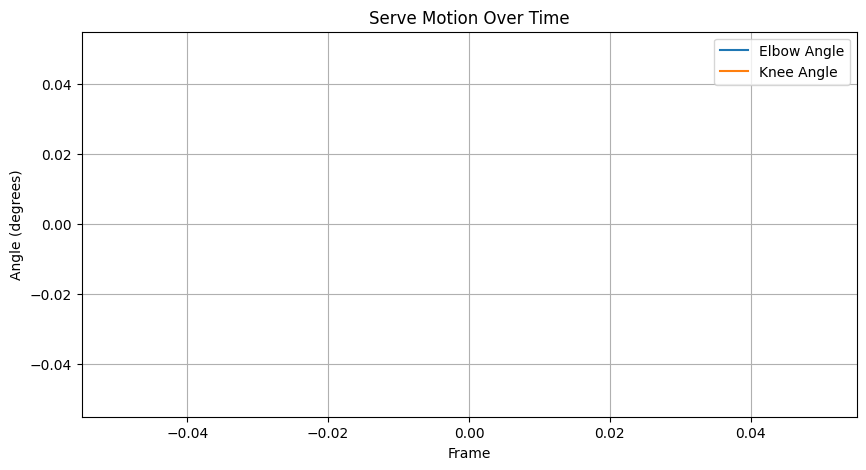

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../outputs/serve_analysis.csv")

plt.figure(figsize=(10,5))
plt.plot(df["frame"], df["elbow_angle"], label="Elbow Angle")
plt.plot(df["frame"], df["knee_angle"], label="Knee Angle")

plt.title("Serve Motion Over Time")
plt.xlabel("Frame")
plt.ylabel("Angle (degrees)")
plt.legend()
plt.grid()
plt.show()

In [13]:
max_frame = df.loc[df["elbow_angle"].idxmax()]
print(max_frame)

ValueError: attempt to get argmax of an empty sequence

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../outputs/serve_analysis.csv")

plt.figure(figsize=(10,5))
plt.plot(df["frame"], df["elbow_angle"], label="Elbow Angle")
plt.plot(df["frame"], df["knee_angle"], label="Knee Angle")
plt.plot(df["frame"], df["wrist_height"], label="Wrist Height")

plt.title("Serve Motion Over Time")
plt.xlabel("Frame")
plt.ylabel("Value")

plt.legend()
plt.grid()
plt.show()

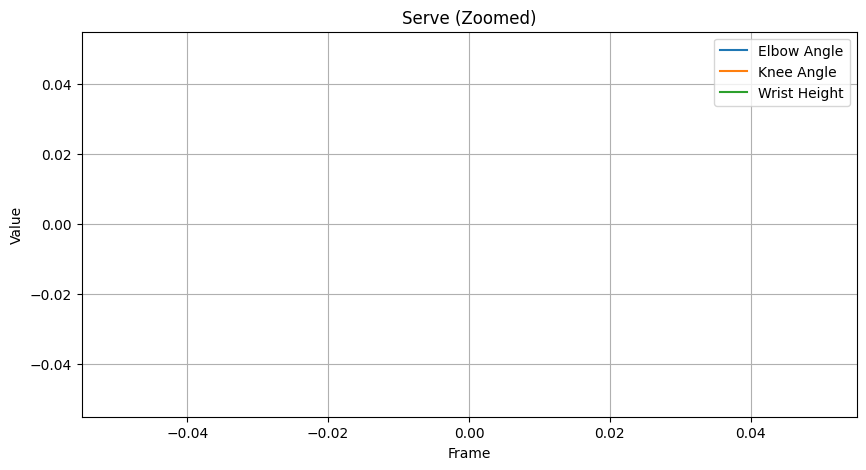

In [17]:


# FILTRAR SOLO UNA PARTE DEL VIDEO (el saque)
df_small = df[(df["frame"] >= 1400) & (df["frame"] <= 1550)]

# GRAFICAR SOLO ESA PARTE
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df_small["frame"], df_small["elbow_angle"], label="Elbow Angle")
plt.plot(df_small["frame"], df_small["knee_angle"], label="Knee Angle")
plt.plot(df_small["frame"], df_small["wrist_height"], label="Wrist Height")

plt.title("Serve (Zoomed)")
plt.xlabel("Frame")
plt.ylabel("Value")

plt.legend()
plt.grid()
plt.show()

Index(['frame', 'elbow_angle', 'knee_angle', 'wrist_height', 'shoulder_angle'], dtype='str')


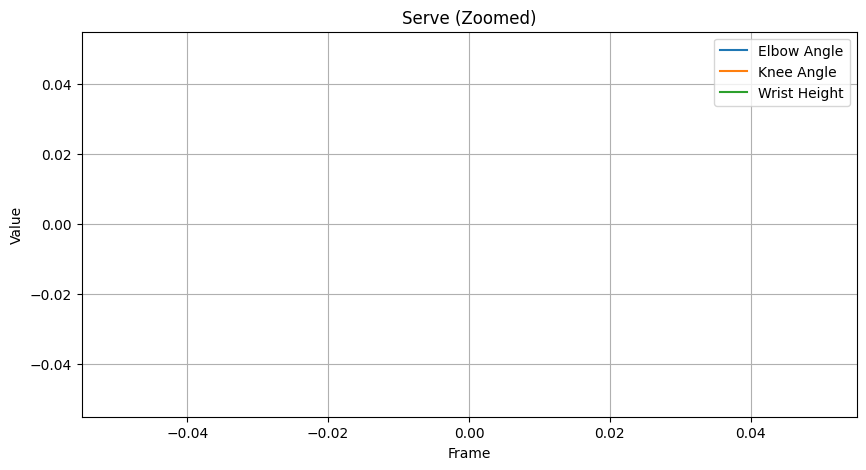

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Leer CSV nuevo
df = pd.read_csv("../outputs/serve_analysis.csv")

# Ver columnas
print(df.columns)

# Quedarnos solo con la parte del saque
df_small = df[(df["frame"] >= 1400) & (df["frame"] <= 1550)]

# Graficar
plt.figure(figsize=(10,5))
plt.plot(df_small["frame"], df_small["elbow_angle"], label="Elbow Angle")
plt.plot(df_small["frame"], df_small["knee_angle"], label="Knee Angle")
plt.plot(df_small["frame"], df_small["wrist_height"], label="Wrist Height")

plt.title("Serve (Zoomed)")
plt.xlabel("Frame")
plt.ylabel("Value")
plt.legend()
plt.grid()
plt.show()

In [ ]:
impact_frame = df_small.loc[
    (df_small["elbow_angle"] > 150) &
    (df_small["wrist_height"] == df_small["wrist_height"].min())
]

print(impact_frame)

      frame  elbow_angle  knee_angle  wrist_height
1466   1467      172.608  174.230555      0.283393


In [ ]:
impact_frame_number = int(impact_frame["frame"].values[0])
print("Impact frame:", impact_frame_number)

Impact frame: 1467


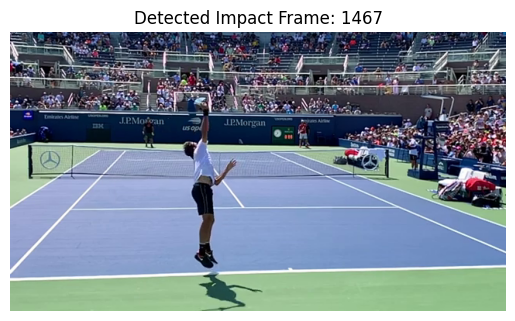

In [19]:
import cv2
import matplotlib.pyplot as plt

video_path = "../data/raw_videos/test_video.mp4"

cap = cv2.VideoCapture(video_path)

cap.set(cv2.CAP_PROP_POS_FRAMES, 1467)

ret, frame = cap.read()

plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title("Detected Impact Frame: 1467")
plt.axis("off")
plt.show()

cap.release()

In [ ]:
import cv2
print("OK")

OK


In [ ]:
import cv2
import numpy as np

video_path = "../data/raw_videos/test_video.mp4"
cap = cv2.VideoCapture(video_path)

prev_gray = None
max_motion = 0
impact_frame = 0
frame_id = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    if prev_gray is not None:
        diff = cv2.absdiff(prev_gray, gray)
        motion = np.sum(diff)

        if motion > max_motion:
            max_motion = motion
            impact_frame = frame_id

    prev_gray = gray
    frame_id += 1

cap.release()

print("Detected impact frame:", impact_frame)

Detected impact frame: 11172


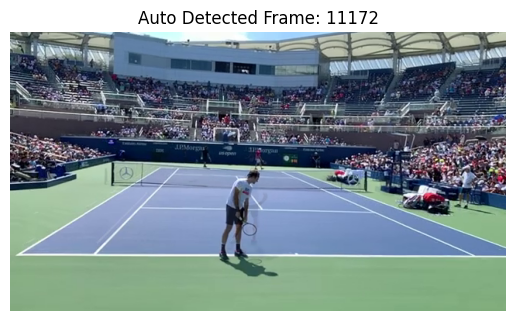

In [ ]:
cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, impact_frame)

ret, frame = cap.read()

plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title(f"Auto Detected Frame: {impact_frame}")
plt.axis("off")
plt.show()

cap.release()

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import cv2

# Leer datos
df = pd.read_csv("../outputs/serve_analysis.csv")

# Quedarnos solo con la parte del saque
df_small = df[(df["frame"] >= 1460) & (df["frame"] <= 1485)].copy()

# Score simple biomecánico:
# codo alto + rodilla extendida - wrist_height (más chico = más arriba)
df_small["score"] = (
    df_small["elbow_angle"] +
    df_small["knee_angle"] -
    (df_small["wrist_height"] * 300)
)

# Elegir el mejor frame
best_row = df_small.loc[df_small["score"].idxmax()]
impact_frame_bio = int(best_row["frame"])

print("Detected impact frame (biomechanics):", impact_frame_bio)
print(best_row)

ValueError: attempt to get argmax of an empty sequence

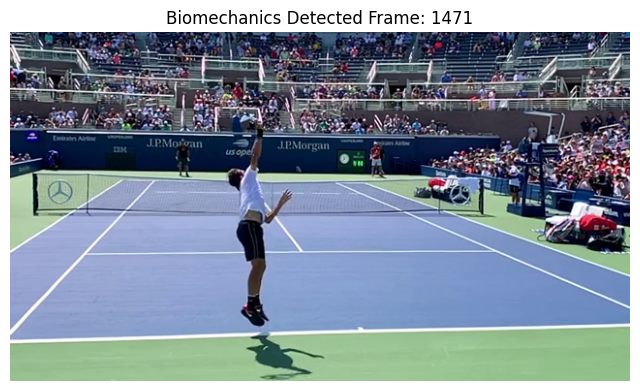

In [ ]:
video_path = "../data/raw_videos/test_video.mp4"

cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, impact_frame_bio)

ret, frame = cap.read()

plt.figure(figsize=(8,5))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title(f"Biomechanics Detected Frame: {impact_frame_bio}")
plt.axis("off")
plt.show()

cap.release()

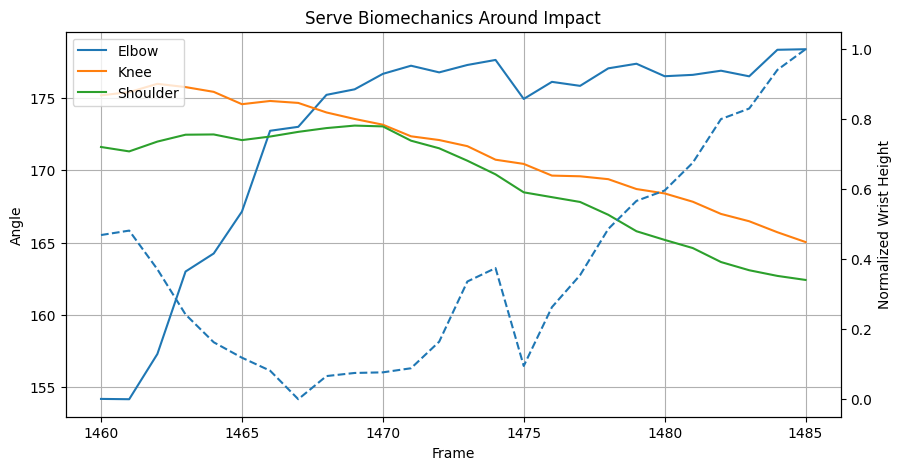

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../outputs/serve_analysis.csv")

df_small = df[(df["frame"] >= 1460) & (df["frame"] <= 1485)]

df_small["wrist_height_norm"] = (
    df_small["wrist_height"] - df_small["wrist_height"].min()
) / (
    df_small["wrist_height"].max() - df_small["wrist_height"].min()
)

fig, ax1 = plt.subplots(figsize=(10,5))

# Eje principal (ángulos)
ax1.plot(df_small["frame"], df_small["elbow_angle"], label="Elbow")
ax1.plot(df_small["frame"], df_small["knee_angle"], label="Knee")
ax1.plot(df_small["frame"], df_small["shoulder_angle"], label="Shoulder")

ax1.set_xlabel("Frame")
ax1.set_ylabel("Angle")
ax1.legend(loc="upper left")
ax1.grid()

# Segundo eje (wrist)
ax2 = ax1.twinx()
ax2.plot(df_small["frame"], df_small["wrist_height_norm"], label="Wrist (Norm)", linestyle='--')
ax2.set_ylabel("Normalized Wrist Height")

plt.title("Serve Biomechanics Around Impact")
plt.show()

In [ ]:
impact_frame = df_small.loc[df_small["wrist_height_norm"].idxmax(), "frame"]
print("Detected impact frame:", impact_frame)

Detected impact frame: 1485


In [ ]:
import pandas as pd

djokovic = pd.read_csv("../outputs/djokovic_analysis.csv")
federer = pd.read_csv("../outputs/federer_analysis.csv")

djokovic.head()

,frame,elbow_angle,knee_angle,wrist_height,shoulder_angle
0,1,175.213683,53.815709,0.808937,174.636059
1,2,175.390970,91.224291,0.808511,174.628060
2,3,176.984796,154.537459,0.807679,176.140112
3,4,179.419240,157.536733,0.806921,177.974641
4,5,178.247313,161.428636,0.806675,176.656453


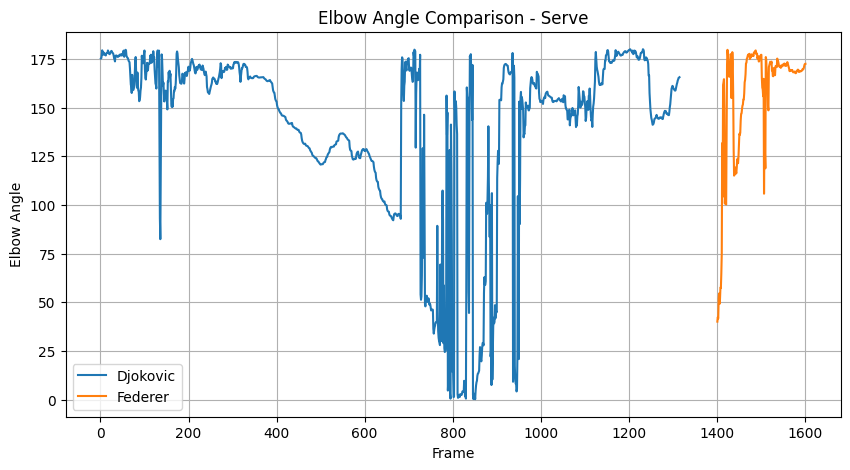

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(djokovic["frame"], djokovic["elbow_angle"], label="Djokovic")
plt.plot(federer["frame"], federer["elbow_angle"], label="Federer")

plt.xlabel("Frame")
plt.ylabel("Elbow Angle")
plt.title("Elbow Angle Comparison - Serve")
plt.legend()
plt.grid()

plt.show()

In [ ]:
djokovic = djokovic[djokovic["elbow_angle"] > 30]
federer = federer[federer["elbow_angle"] > 30]

In [ ]:
djokovic["normalized_time"] = djokovic["frame"] / djokovic["frame"].max()
federer["normalized_time"] = federer["frame"] / federer["frame"].max()

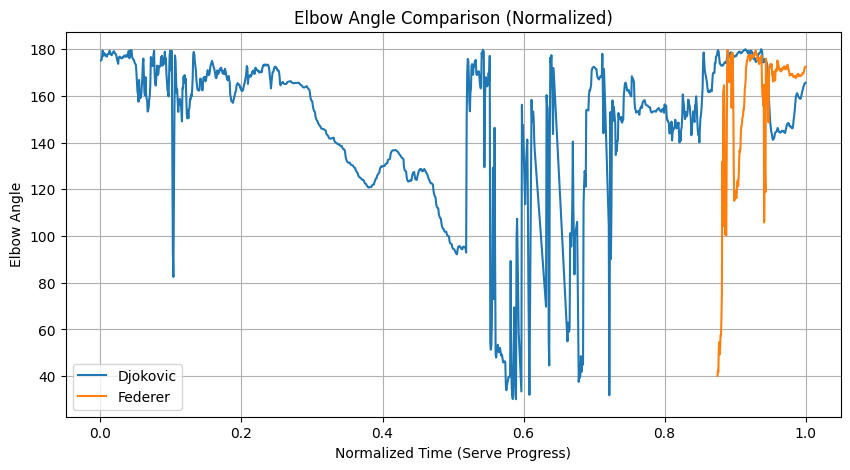

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(djokovic["normalized_time"], djokovic["elbow_angle"], label="Djokovic")
plt.plot(federer["normalized_time"], federer["elbow_angle"], label="Federer")

plt.xlabel("Normalized Time (Serve Progress)")
plt.ylabel("Elbow Angle")
plt.title("Elbow Angle Comparison (Normalized)")
plt.legend()
plt.grid()

plt.show()

In [ ]:
djokovic_impact = djokovic.loc[djokovic["elbow_angle"].idxmax()]
federer_impact = federer.loc[federer["elbow_angle"].idxmax()]

print("Djokovic impact:")
print(djokovic_impact)

print("\nFederer impact:")
print(federer_impact)

Djokovic impact:
frame              1232.000000
elbow_angle         179.992328
knee_angle          178.630581
wrist_height          0.591920
shoulder_angle       18.410180
normalized_time       0.936882
Name: 1230, dtype: float64

Federer impact:
frame              1424.000000
elbow_angle         179.681609
knee_angle          172.951210
wrist_height          0.463825
shoulder_angle      148.606995
normalized_time       0.889444
Name: 23, dtype: float64


In [ ]:
print("Elbow angle at impact:")
print("Djokovic:", djokovic_impact["elbow_angle"])
print("Federer:", federer_impact["elbow_angle"])

print("\nKnee angle at impact:")
print("Djokovic:", djokovic_impact["knee_angle"])
print("Federer:", federer_impact["knee_angle"])

Elbow angle at impact:
Djokovic: 179.99232769747934
Federer: 179.68160851868012

Knee angle at impact:
Djokovic: 178.63058061397422
Federer: 172.9512096527123


In [ ]:
window = 40

djokovic_impact_frame = int(djokovic_impact["frame"])
federer_impact_frame = int(federer_impact["frame"])

djokovic_window = djokovic[
    (djokovic["frame"] >= djokovic_impact_frame - window) &
    (djokovic["frame"] <= djokovic_impact_frame + window)
].copy()

federer_window = federer[
    (federer["frame"] >= federer_impact_frame - window) &
    (federer["frame"] <= federer_impact_frame + window)
].copy()

djokovic_window["relative_frame"] = djokovic_window["frame"] - djokovic_impact_frame
federer_window["relative_frame"] = federer_window["frame"] - federer_impact_frame

print(djokovic_window.head())
print(federer_window.head())

      frame  elbow_angle  knee_angle  wrist_height  shoulder_angle  \
1190   1192   178.992236  173.868796      0.583645       10.014671   
1191   1193   178.894179  174.666686      0.582891       10.252323   
1192   1194   178.257563  175.674719      0.582113       10.773485   
1193   1195   178.306200  176.661457      0.581970       11.063903   
1194   1196   178.477532  177.384089      0.582206       11.168201   

      normalized_time  relative_frame  
1190         0.906464             -40  
1191         0.907224             -39  
1192         0.907985             -38  
1193         0.908745             -37  
1194         0.909506             -36  
   frame  elbow_angle  knee_angle  wrist_height  shoulder_angle  \
0   1401    40.112637  161.543541      0.525792       22.361445   
1   1402    42.419606  161.673586      0.523624       24.840181   
2   1403    41.742522  161.840128      0.522591       25.188436   
3   1404    52.124182  162.368777      0.518294       30.572406   
4   

In [ ]:
djokovic_window["elbow_smooth"] = djokovic_window["elbow_angle"].rolling(3).mean()
federer_window["elbow_smooth"] = federer_window["elbow_angle"].rolling(3).mean()

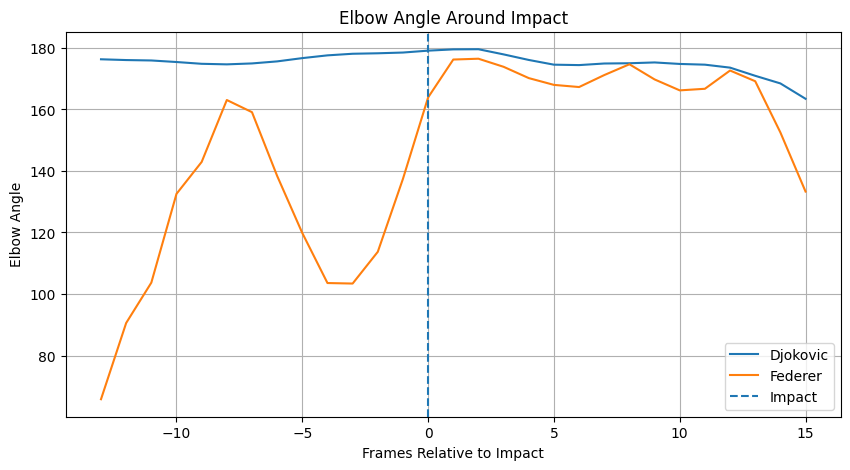

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(djokovic_window["relative_frame"], djokovic_window["elbow_smooth"], label="Djokovic")
plt.plot(federer_window["relative_frame"], federer_window["elbow_smooth"], label="Federer")

plt.axvline(0, linestyle="--", label="Impact")

plt.xlabel("Frames Relative to Impact")
plt.ylabel("Elbow Angle")
plt.title("Elbow Angle Around Impact")
plt.legend()
plt.grid()
plt.show()

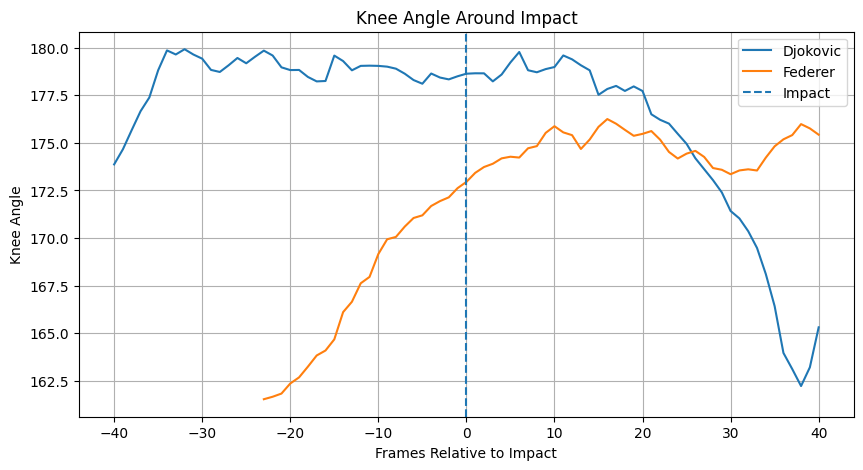

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(djokovic_window["relative_frame"], djokovic_window["knee_angle"], label="Djokovic")
plt.plot(federer_window["relative_frame"], federer_window["knee_angle"], label="Federer")

plt.axvline(0, linestyle="--", label="Impact")

plt.xlabel("Frames Relative to Impact")
plt.ylabel("Knee Angle")
plt.title("Knee Angle Around Impact")
plt.legend()
plt.grid()
plt.show()

In [ ]:
print("Djokovic elbow range:", djokovic_window["elbow_angle"].min(), djokovic_window["elbow_angle"].max())
print("Federer elbow range:", federer_window["elbow_angle"].min(), federer_window["elbow_angle"].max())

print("Djokovic knee range:", djokovic_window["knee_angle"].min(), djokovic_window["knee_angle"].max())
print("Federer knee range:", federer_window["knee_angle"].min(), federer_window["knee_angle"].max())

Djokovic elbow range: 141.20729889298485 179.99232769747934
Federer elbow range: 40.11263729134252 179.68160851868012
Djokovic knee range: 162.23547134565104 179.91583160087384
Federer knee range: 161.54354145358715 176.25014460758968


In [ ]:
print("Djokovic elbow range:", djokovic_window["elbow_angle"].min(), djokovic_window["elbow_angle"].max())
print("Federer elbow range:", federer_window["elbow_angle"].min(), federer_window["elbow_angle"].max())

print("Djokovic knee range:", djokovic_window["knee_angle"].min(), djokovic_window["knee_angle"].max())
print("Federer knee range:", federer_window["knee_angle"].min(), federer_window["knee_angle"].max())

Djokovic elbow range: 141.20729889298485 179.99232769747934
Federer elbow range: 40.11263729134252 179.68160851868012
Djokovic knee range: 162.23547134565104 179.91583160087384
Federer knee range: 161.54354145358715 176.25014460758968


In [ ]:
djokovic_window["elbow_velocity"] = djokovic_window["elbow_smooth"].diff()
federer_window["elbow_velocity"] = federer_window["elbow_smooth"].diff()

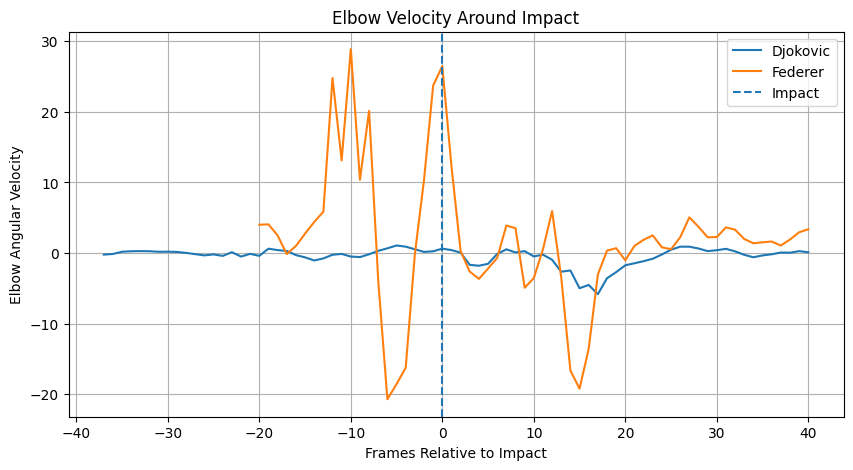

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(djokovic_window["relative_frame"], djokovic_window["elbow_velocity"], label="Djokovic")
plt.plot(federer_window["relative_frame"], federer_window["elbow_velocity"], label="Federer")

plt.axvline(0, linestyle="--", label="Impact")

plt.xlabel("Frames Relative to Impact")
plt.ylabel("Elbow Angular Velocity")
plt.title("Elbow Velocity Around Impact")

plt.legend()
plt.grid()
plt.show()

In [ ]:
djokovic_window["elbow_velocity_raw"] = djokovic_window["elbow_angle"].diff()
federer_window["elbow_velocity_raw"] = federer_window["elbow_angle"].diff()

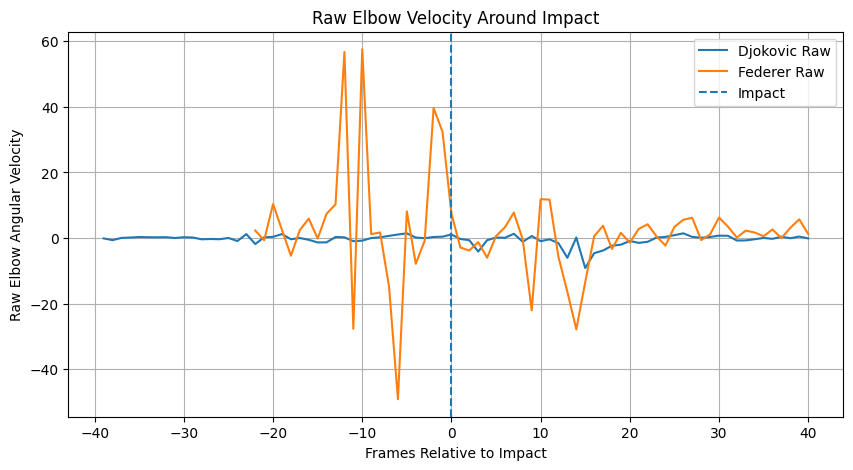

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(djokovic_window["relative_frame"], djokovic_window["elbow_velocity_raw"], label="Djokovic Raw")
plt.plot(federer_window["relative_frame"], federer_window["elbow_velocity_raw"], label="Federer Raw")

plt.axvline(0, linestyle="--", label="Impact")

plt.xlabel("Frames Relative to Impact")
plt.ylabel("Raw Elbow Angular Velocity")
plt.title("Raw Elbow Velocity Around Impact")
plt.legend()
plt.grid()
plt.show()

In [ ]:
djokovic_window["shoulder_velocity"] = djokovic_window["shoulder_angle"].diff()
federer_window["shoulder_velocity"] = federer_window["shoulder_angle"].diff()

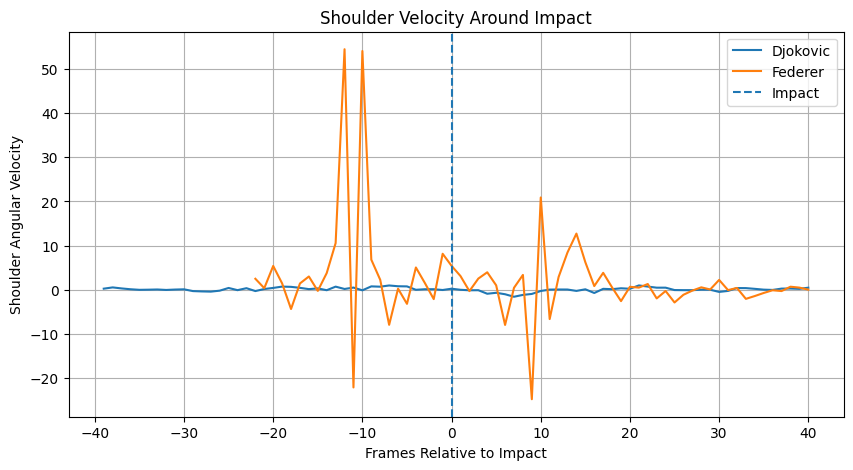

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(djokovic_window["relative_frame"], djokovic_window["shoulder_velocity"], label="Djokovic")
plt.plot(federer_window["relative_frame"], federer_window["shoulder_velocity"], label="Federer")

plt.axvline(0, linestyle="--", label="Impact")

plt.xlabel("Frames Relative to Impact")
plt.ylabel("Shoulder Angular Velocity")
plt.title("Shoulder Velocity Around Impact")

plt.legend()
plt.grid()
plt.show()

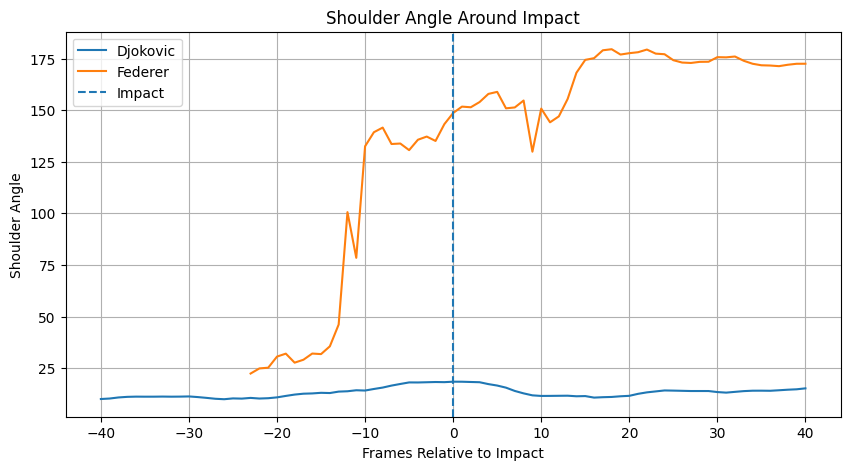

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(djokovic_window["relative_frame"], djokovic_window["shoulder_angle"], label="Djokovic")
plt.plot(federer_window["relative_frame"], federer_window["shoulder_angle"], label="Federer")

plt.axvline(0, linestyle="--", label="Impact")

plt.xlabel("Frames Relative to Impact")
plt.ylabel("Shoulder Angle")
plt.title("Shoulder Angle Around Impact")
plt.legend()
plt.grid()
plt.show()

In [ ]:
print("Djokovic shoulder range:", djokovic_window["shoulder_angle"].min(), djokovic_window["shoulder_angle"].max())
print("Federer shoulder range:", federer_window["shoulder_angle"].min(), federer_window["shoulder_angle"].max())

Djokovic shoulder range: 9.915143538626657 18.410179824284544
Federer shoulder range: 22.361445451778597 179.51559859844704


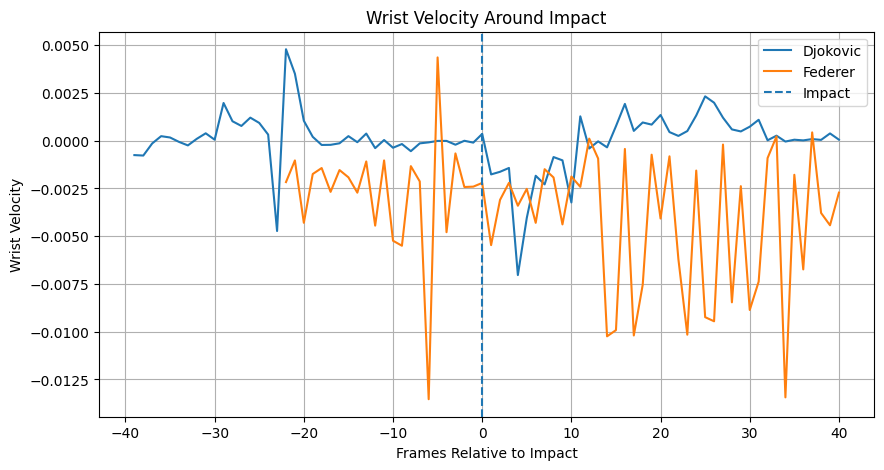

In [ ]:
djokovic_window["wrist_velocity"] = djokovic_window["wrist_height"].diff()
federer_window["wrist_velocity"] = federer_window["wrist_height"].diff()

plt.figure(figsize=(10,5))

plt.plot(djokovic_window["relative_frame"], djokovic_window["wrist_velocity"], label="Djokovic")
plt.plot(federer_window["relative_frame"], federer_window["wrist_velocity"], label="Federer")

plt.axvline(0, linestyle="--", label="Impact")

plt.xlabel("Frames Relative to Impact")
plt.ylabel("Wrist Velocity")
plt.title("Wrist Velocity Around Impact")
plt.legend()
plt.grid()
plt.show()

In [ ]:
djokovic_window["wrist_velocity_smooth"] = djokovic_window["wrist_velocity"].rolling(3).mean()
federer_window["wrist_velocity_smooth"] = federer_window["wrist_velocity"].rolling(3).mean()

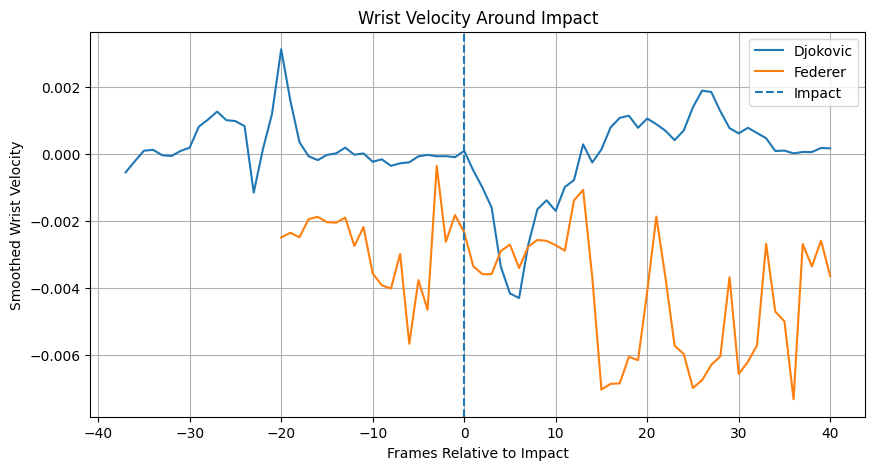

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(djokovic_window["relative_frame"], djokovic_window["wrist_velocity_smooth"], label="Djokovic")
plt.plot(federer_window["relative_frame"], federer_window["wrist_velocity_smooth"], label="Federer")

plt.axvline(0, linestyle="--", label="Impact")

plt.xlabel("Frames Relative to Impact")
plt.ylabel("Smoothed Wrist Velocity")
plt.title("Wrist Velocity Around Impact")
plt.legend()
plt.grid()
plt.show()

In [ ]:
print("Djokovic elbow angle at impact:", djokovic_impact["elbow_angle"])
print("Federer elbow angle at impact:", federer_impact["elbow_angle"])

print("Djokovic knee angle at impact:", djokovic_impact["knee_angle"])
print("Federer knee angle at impact:", federer_impact["knee_angle"])

print("Djokovic max wrist velocity:", djokovic_window["wrist_velocity_smooth"].max())
print("Federer max wrist velocity:", federer_window["wrist_velocity_smooth"].max())

Djokovic elbow angle at impact: 179.99232769747934
Federer elbow angle at impact: 179.68160851868012
Djokovic knee angle at impact: 178.63058061397422
Federer knee angle at impact: 172.9512096527123
Djokovic max wrist velocity: 0.0031119187672932944
Federer max wrist velocity: -0.0003657142321268532


In [ ]:
amateur_df = pd.read_csv("../outputs/amateur_analysis.csv")

In [ ]:
amateur_impact = amateur_df.loc[amateur_df["wrist_height"].idxmax()]
amateur_impact_frame = int(amateur_impact["frame"])

In [ ]:
window = 40

amateur_window = amateur_df[
    (amateur_df["frame"] >= amateur_impact_frame - window) &
    (amateur_df["frame"] <= amateur_impact_frame + window)
].copy()

amateur_window["relative_frame"] = amateur_window["frame"] - amateur_impact_frame

In [ ]:
amateur_window["wrist_velocity"] = amateur_window["wrist_height"].diff()
amateur_window["wrist_velocity_smooth"] = amateur_window["wrist_velocity"].rolling(3).mean()

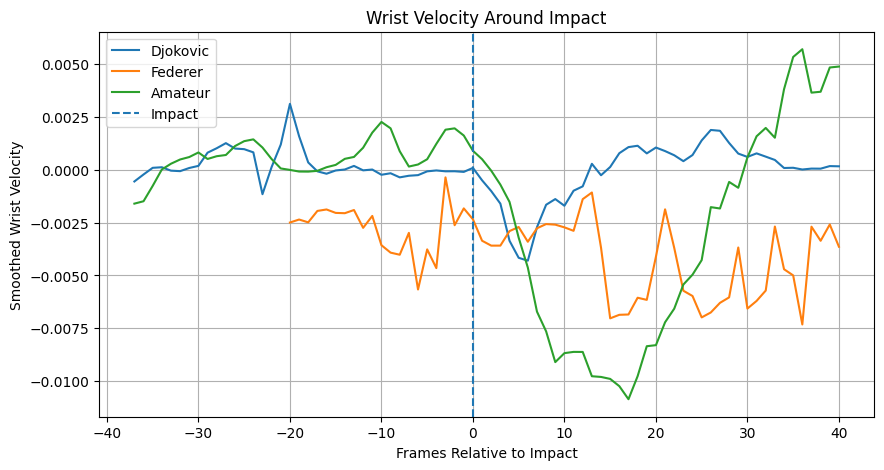

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(djokovic_window["relative_frame"], djokovic_window["wrist_velocity_smooth"], label="Djokovic")
plt.plot(federer_window["relative_frame"], federer_window["wrist_velocity_smooth"], label="Federer")
plt.plot(amateur_window["relative_frame"], amateur_window["wrist_velocity_smooth"], label="Amateur")

plt.axvline(0, linestyle="--", label="Impact")

plt.xlabel("Frames Relative to Impact")
plt.ylabel("Smoothed Wrist Velocity")
plt.title("Wrist Velocity Around Impact")
plt.legend()
plt.grid()
plt.show()

In [ ]:
print("Amateur elbow angle at impact:", amateur_impact["elbow_angle"])
print("Amateur knee angle at impact:", amateur_impact["knee_angle"])
print("Amateur max wrist velocity:", amateur_window["wrist_velocity_smooth"].abs().max())

Amateur elbow angle at impact: 156.64864290943814
Amateur knee angle at impact: 163.87036791713518
Amateur max wrist velocity: 0.01085446278254191


In [15]:
def normalize_time(df):
    df = df.copy()
    df = df.sort_values("frame")
    
    min_frame = df["frame"].min()
    max_frame = df["frame"].max()
    
    df["time_norm"] = (df["frame"] - min_frame) / (max_frame - min_frame)
    
    return df

In [16]:
djokovic_norm = normalize_time(djokovic_window)
federer_norm = normalize_time(federer_window)
amateur_norm = normalize_time(amateur_window)

NameError: name 'djokovic_window' is not defined

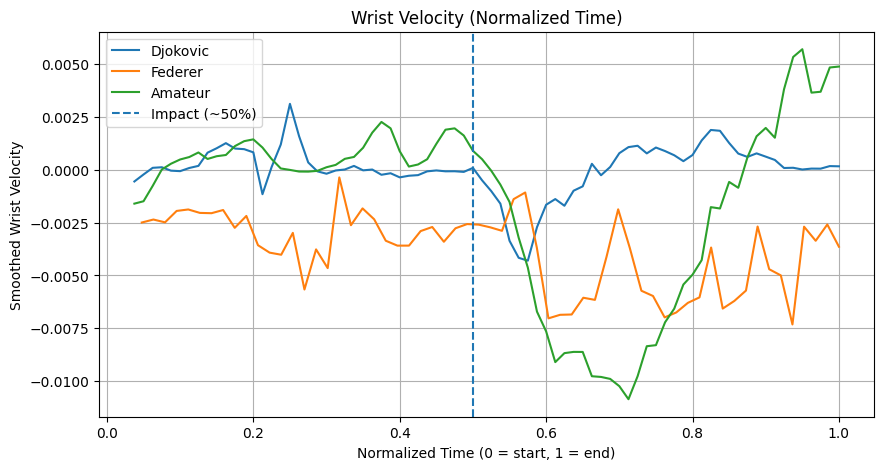

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(djokovic_norm["time_norm"], djokovic_norm["wrist_velocity_smooth"], label="Djokovic")
plt.plot(federer_norm["time_norm"], federer_norm["wrist_velocity_smooth"], label="Federer")
plt.plot(amateur_norm["time_norm"], amateur_norm["wrist_velocity_smooth"], label="Amateur")

plt.axvline(0.5, linestyle="--", label="Impact (~50%)")

plt.xlabel("Normalized Time (0 = start, 1 = end)")
plt.ylabel("Smoothed Wrist Velocity")
plt.title("Wrist Velocity (Normalized Time)")
plt.legend()
plt.grid()
plt.show()

In [ ]:
summary = pd.DataFrame({
    "Player": ["Djokovic", "Federer", "Amateur"],
    "Elbow Angle": [
        djokovic_impact["elbow_angle"],
        federer_impact["elbow_angle"],
        amateur_impact["elbow_angle"]
    ],
    "Knee Angle": [
        djokovic_impact["knee_angle"],
        federer_impact["knee_angle"],
        amateur_impact["knee_angle"]
    ]
})

print(summary)

     Player  Elbow Angle  Knee Angle
0  Djokovic   179.992328  178.630581
1   Federer   179.681609  172.951210
2   Amateur   156.648643  163.870368


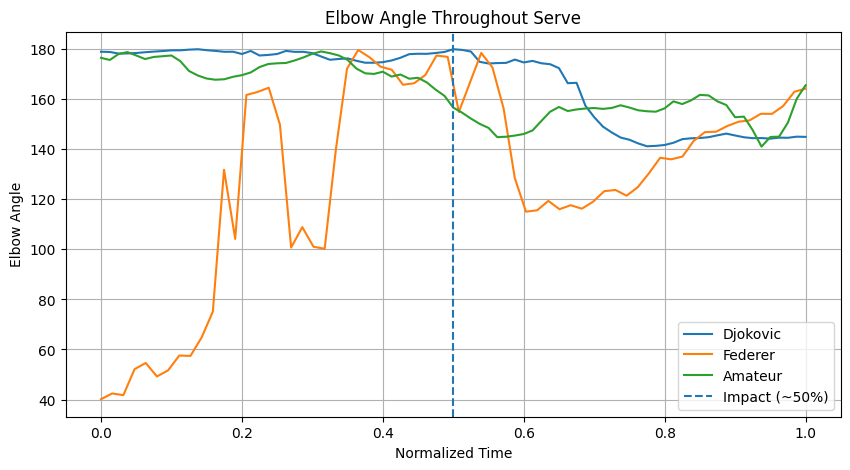

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(djokovic_norm["time_norm"], djokovic_norm["elbow_angle"], label="Djokovic")
plt.plot(federer_norm["time_norm"], federer_norm["elbow_angle"], label="Federer")
plt.plot(amateur_norm["time_norm"], amateur_norm["elbow_angle"], label="Amateur")

plt.axvline(0.5, linestyle="--", label="Impact (~50%)")

plt.xlabel("Normalized Time")
plt.ylabel("Elbow Angle")
plt.title("Elbow Angle Throughout Serve")
plt.legend()
plt.grid()
plt.show()